<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 44px 36px; border-radius: 16px; text-align: center; margin-bottom: 24px;">
    <h1 style="color: #f0c040; font-size: 2.4em; margin: 0 0 10px 0; font-weight: 800; letter-spacing: 1px;">
        📑 Financial NLP: Decoding 10-K Disclosures
    </h1>
    <h3 style="color: #b0c4de; font-weight: 400; margin: 0 0 22px 0; font-size: 1.1em;">
        A Professional Text-Analytics Pipeline on SEC Annual Filings
    </h3>
    <div style="display: flex; justify-content: center; gap: 10px; flex-wrap: wrap;">
        <span style="background:#e67e22;color:white;padding:4px 14px;border-radius:20px;font-size:.82em;">Python 3.10</span>
        <span style="background:#1a7abf;color:white;padding:4px 14px;border-radius:20px;font-size:.82em;">NLTK</span>
        <span style="background:#27ae60;color:white;padding:4px 14px;border-radius:20px;font-size:.82em;">scikit-learn</span>
        <span style="background:#8e44ad;color:white;padding:4px 14px;border-radius:20px;font-size:.82em;">Gensim LDA</span>
        <span style="background:#c0392b;color:white;padding:4px 14px;border-radius:20px;font-size:.82em;">SEC 10-K Data</span>
    </div>
</div>

## Abstract

Every year, public companies file a **10-K annual report** with the U.S. Securities and Exchange Commission (SEC). Buried inside is a *Risk Factors* section — a dense, legally-crafted block of prose that reveals management's true fears: competitive threats, regulatory exposure, talent attrition, and more.

This notebook builds a **complete NLP pipeline** that transforms unstructured 10-K prose into structured, quantifiable signals. Starting from raw text, we progress through 12 analytical techniques — each one adding a new lens through which to read financial language.

### Who is this for?
| Audience | Value |
|----------|-------|
| **Quant / NLP practitioners** | End-to-end reproducible pipeline with professional visualisations |
| **Finance professionals** | Understand what NLP can extract from disclosures and why it matters |
| **Students / beginners** | Each concept explained before the code, with financial context |

### Pipeline overview
```
Raw 10-K Text
    → Tokenisation  → Normalisation  → Cleaning
        → Frequency  → N-grams  → POS Tagging
            → Bag-of-Words  → TF-IDF  → Similarity
                → Readability  → Sentiment  → Topic Modelling
```
---

## Table of Contents

0. [Environment Setup](#0)
1. [Load & Explore 10-K Data](#1)
2. [Tokenisation](#2)
3. [Stemming & Lemmatisation](#3)
4. [Stop-Word Removal](#4)
5. [Word Frequency Analysis](#5)
6. [N-grams & Collocations](#6)
7. [Part-of-Speech Tagging](#7)
8. [Bag-of-Words & TF-IDF](#8)
9. [Document Similarity](#9)
10. [Readability Indices](#10)
11. [Sentiment Analysis](#11)
12. [Topic Modelling (LDA + NMF)](#12)
13. [Integrated Dashboard](#13)
14. [Key Takeaways & Next Steps](#14)

---

## Environment Setup

In [7]:
# #Install required libraries (run once)
!pip install "wordcloud>=1.9.2" "gensim>=4.0" "textstat>=0.7" \
             "matplotlib>=3.7.0" "numpy>=1.24.0" "Pillow>=9.5.0" \
             "pandas>=1.5.0" "beautifulsoup4>=4.9.0" "scikit-learn>=1.0" \
             "lxml>=4.6.0" "nltk>=3.7.0" -q

In [8]:
import re, string, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.collocations import (BigramCollocationFinder, TrigramCollocationFinder,
                                BigramAssocMeasures, TrigramAssocMeasures)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF

import textstat
from gensim.models import LdaModel
from gensim.corpora import Dictionary

warnings.filterwarnings('ignore')

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.titlesize": 13})

COLOR_POS  = "#27ae60"   # green
COLOR_NEG  = "#e74c3c"   # red
COLOR_UNC  = "#e67e22"   # orange
COLOR_MAIN = "#2980b9"   # blue

# ── NLTK resources ────────────────────────────────────────────────────────────
NLTK_RESOURCES = ['punkt', 'punkt_tab', 'stopwords',
                  'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
                  'wordnet', 'omw-1.4']
for r in NLTK_RESOURCES:
    try:
        nltk.download(r, quiet=True)
    except Exception:
        pass

print("✅ Environment ready")
print(f"   numpy   {np.__version__}  |  pandas {pd.__version__}")

✅ Environment ready
   numpy   2.0.2  |  pandas 2.3.3


## Load & Explore Data

### What is a 10-K?

A **10-K** is the most important document a public company files each year with the SEC. It contains:

| Section | Content |
|---------|---------|
| Business | What the company does |
| Risk Factors | ⚠️ What could go wrong — *our focus* |
| MD&A | Management's analysis of financials |
| Financial Statements | Audited numbers |

The **Risk Factors** section is a goldmine for NLP: it is written by lawyers, vetted by executives, and required to disclose *all material risks* — making it the most information-dense qualitative section.

> 📌 **Data source:** Sample 10-K Risk Factors text from a SaaS marketing-technology company. In Section 14 we show how to scale this to real SEC filings via the EDGAR API.

In [9]:
financial_text = """Risks Related To Our Business
The majority of our products and services are sold pursuant to short-term subscription agreements, and if our customers elect not to renew these agreements, our revenues may decrease — a clear revenue risk for our business.
Typically, our products and services are sold pursuant to short-term subscription agreements, which are generally one month to one year in length, with no obligation to renew these agreements; this creates renewal-rate risk that we continuously monitor.
Our renewal rates may decline due to a variety of factors, including the products and prices offered by competitors, new technologies, consolidation in our customer base, or if some of our customers cease operations — each representing potential operational or market risk.
If our renewal rates are low or decline for any reason, or if customers renew on less favorable terms, our revenues may decrease, which could adversely affect our stock price and increase financial risk for stakeholders.
We may not be able to scale our business quickly enough to meet our customers' growing needs, and if we are not able to grow efficiently, our operating results could be harmed by execution risk.
As usage of our marketing software grows and as customers use our solutions for more advanced programs, we will need to devote additional resources to improving our application architecture, integrating with third-party systems, and maintaining infrastructure performance — exposing us to integration and performance risk.
If we fail to enhance our existing products and services or develop new products and services, our offerings may become obsolete or less competitive, creating product obsolescence risk and causing us to lose customers.
If we are unable to keep pace with rapid technological developments and meet our customers' needs, our business will be harmed and strategic risk will increase.
Creating and designing such enhancements and new products entail significant technical and business risk and require substantial expenditures and lead time.
We face significant threats from new entrants to our business, which could cause us to suffer a decline in revenues and profitability — competitive risk that could materially affect our results.
Barriers to entry in marketing technology markets are relatively low, and new market entrants may intensify this competitive risk.
Privately backed and public companies could choose to enter our space and compete directly with us, or indirectly by offering substitute solutions.
The market in which we participate is competitive and, if we do not compete effectively, our operating results could be harmed.
Our principal competitors include marketing automation companies like HubSpot, Marketo and Act-On.
We are a small public company; the requirements of being public strain our systems and resources and introduce compliance and governance risk.
We depend on search engines to attract a significant percentage of our customers, and algorithm changes pose acquisition risk.
Many of our customers locate our website by clicking through on search results displayed by search engines such as Google and Yahoo.
Search engines revise their algorithms from time to time in an attempt to optimize their search result listings, which can create unpredictability and marketing risk.
We depend on email to market to and communicate with our customers, and interruptions or regulation changes could create communication risk.
Our customers rely on email to communicate with their constituents.
Our future depends on our ability to attract and retain key personnel; talent retention risk could impede our growth.
Our success will depend in part on the ability of our management team to effectively manage our growth and mitigate these various risks.
If we fail to retain our key personnel, we may not be able to achieve our anticipated level of growth and our business could suffer."""

# ── Basic statistics ───────────────────────────────────────────────────────────
sentences  = sent_tokenize(financial_text)
all_words  = word_tokenize(financial_text.lower())
num_chars  = len(financial_text)
avg_wps    = len(all_words) / len(sentences)

stats = {
    "Characters": f"{num_chars:,}",
    "Sentences":  len(sentences),
    "Words (tokens)": len(all_words),
    "Avg words / sentence": f"{avg_wps:.1f}",
    "Unique words": len(set(all_words)),
    "Type-Token Ratio": f"{len(set(all_words))/len(all_words):.3f}",
}

print("=" * 55)
print("  10-K RISK SECTION — DOCUMENT STATISTICS")
print("=" * 55)
for k, v in stats.items():
    print(f"  {k:<28}: {v}")

print(f"\n📄 First 3 sentences:")
print("-" * 55)
for i, s in enumerate(sentences[:3], 1):
    print(f"  [{i}] {s[:120]}{'…' if len(s)>120 else ''}")

# Save for later sections
original_text = financial_text
all_sentences = sentences

  10-K RISK SECTION — DOCUMENT STATISTICS
  Characters                  : 3,925
  Sentences                   : 23
  Words (tokens)              : 666
  Avg words / sentence        : 29.0
  Unique words                : 266
  Type-Token Ratio            : 0.399

📄 First 3 sentences:
-------------------------------------------------------
  [1] Risks Related To Our Business
The majority of our products and services are sold pursuant to short-term subscription agr…
  [2] Typically, our products and services are sold pursuant to short-term subscription agreements, which are generally one mo…
  [3] Our renewal rates may decline due to a variety of factors, including the products and prices offered by competitors, new…


<a id='2'></a>
## Tokenisation

**Tokenisation** is the process of splitting raw text into discrete units — *tokens* — that can be counted, indexed, or fed into models. It is the unavoidable first step of every NLP pipeline.

Two levels:
- **Sentence tokenisation** — split text into complete sentences (needed for readability, POS tagging)
- **Word tokenisation** — split each sentence into individual words or punctuation marks

**Why NLTK over `.split()`?**  
`split()` treats `"products,"` as one token. NLTK's `word_tokenize` correctly separates the comma, giving accurate frequency counts. The difference compounds at scale: a 500-word document might have 30–40 tokens mis-counted by naive splitting.

 SENTENCE TOKENISATION
-------------------------------------------------------
Total sentences: 23
  [1] Risks Related To Our Business
The majority of our products and services are sold pursuant to short-t…
  [2] Typically, our products and services are sold pursuant to short-term subscription agreements, which …
  [3] Our renewal rates may decline due to a variety of factors, including the products and prices offered…

 WORD TOKENISATION — naive split vs NLTK
-------------------------------------------------------
  Naive  ( 9 tokens): ['We', 'failed', 'to', 'enhance', 'our', 'products,', 'services,', 'and', 'infrastructure.']
  NLTK   (12 tokens): ['We', 'failed', 'to', 'enhance', 'our', 'products', ',', 'services', ',', 'and', 'infrastructure', '.']

  Naive — tokens containing punctuation: ['products,', 'services,', 'infrastructure.']
  NLTK  — punctuation as own tokens    : [',', ',', '.']

  💡 NLTK separates punctuation, so word counts are accurate.


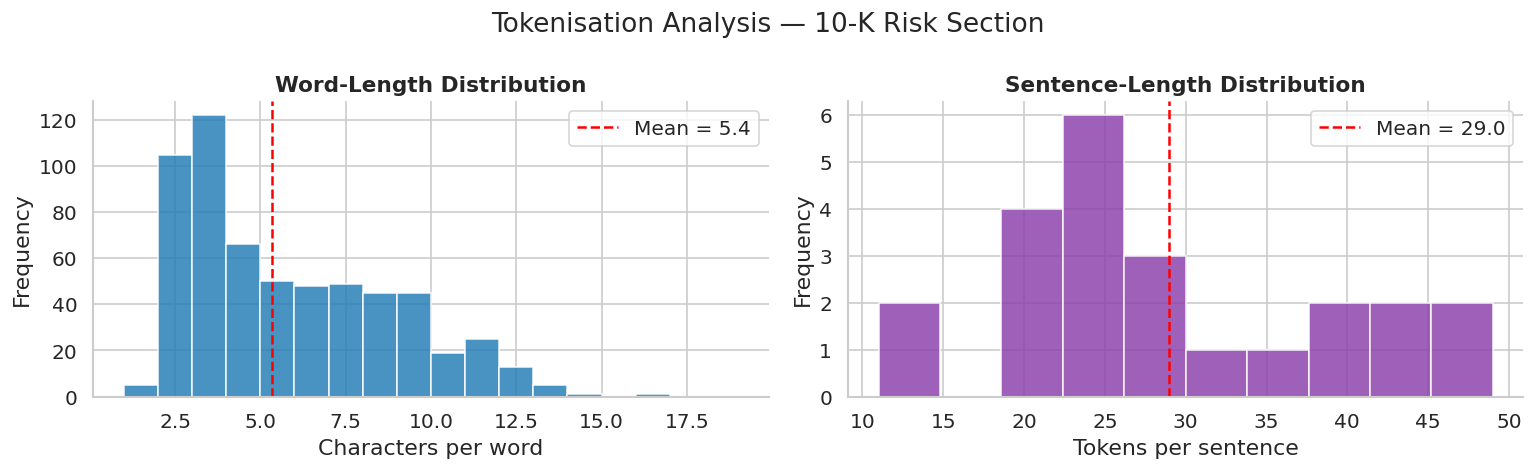


✅ Tokenisation complete | 666 word tokens | 23 sentences


In [10]:
print(" SENTENCE TOKENISATION")
print("-" * 55)
print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences[:3], 1):
    print(f"  [{i}] {s[:100]}…")

print("\n WORD TOKENISATION — naive split vs NLTK")
print("-" * 55)

sample = "We failed to enhance our products, services, and infrastructure."
naive  = sample.split()
nltk_t = word_tokenize(sample)

comparison = pd.DataFrame({
    "Method":     ["Naive split"] * len(naive) + ["NLTK"] * len(nltk_t),
    "Token":      naive + nltk_t,
    "Index":      list(range(len(naive))) + list(range(len(nltk_t)))
})
print(f"  Naive  ({len(naive):2d} tokens): {naive}")
print(f"  NLTK   ({len(nltk_t):2d} tokens): {nltk_t}")
print()

# Highlight the difference
naive_punct = [t for t in naive if any(p in t for p in string.punctuation)]
nltk_punct  = [t for t in nltk_t if t in string.punctuation]
print(f"  Naive — tokens containing punctuation: {naive_punct}")
print(f"  NLTK  — punctuation as own tokens    : {nltk_punct}")
print()
print(f"  💡 NLTK separates punctuation, so word counts are accurate.")

# ── Word-length distribution ───────────────────────────────────────────────────
alpha_words = [w for w in all_words if w.isalpha()]
lengths = [len(w) for w in alpha_words]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Tokenisation Analysis — 10-K Risk Section")

axes[0].hist(lengths, bins=range(1, 20), color=COLOR_MAIN, edgecolor='white', alpha=0.85)
axes[0].set_title("Word-Length Distribution")
axes[0].set_xlabel("Characters per word")
axes[0].set_ylabel("Frequency")
axes[0].axvline(np.mean(lengths), color='red', linestyle='--', label=f"Mean = {np.mean(lengths):.1f}")
axes[0].legend()

# Sentence-length distribution
sent_lengths = [len(word_tokenize(s)) for s in sentences]
axes[1].hist(sent_lengths, bins=10, color="#8e44ad", edgecolor='white', alpha=0.85)
axes[1].set_title("Sentence-Length Distribution")
axes[1].set_xlabel("Tokens per sentence")
axes[1].set_ylabel("Frequency")
axes[1].axvline(np.mean(sent_lengths), color='red', linestyle='--', label=f"Mean = {np.mean(sent_lengths):.1f}")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

print(f"\n✅ Tokenisation complete | {len(all_words):,} word tokens | {len(sentences)} sentences")

## Stemming & Lemmatisation

Both techniques **normalise** word forms to reduce vocabulary size, but they work differently:

| | Stemming | Lemmatisation |
|-|---------|---------------|
| **How** | Chops suffixes by rule | Looks up the dictionary base form |
| **Speed** | Fast | Slower |
| **Output** | May not be a real word (`"corpor"`) | Always a valid word (`"corporation"`) |
| **Best for** | Search indexing, large corpora | Analysis where interpretability matters |

**Finance context:** Without normalisation, a model treats `"risks"`, `"risky"`, and `"risk"` as three separate features, diluting the signal. After lemmatisation they all map to `"risk"` — the concept the analyst cares about.

STEMMING vs LEMMATISATION — Financial Vocabulary
   Original    Stemmed  Lemmatized  Same as original?
     invest     invest      invest               True
  investing     invest      invest              False
 investment     invest  investment               True
investments     invest  investment              False
       risk       risk        risk               True
      risky      riski       risky               True
      risks       risk        risk              False
    risking       risk        risk              False
    revenue     revenu     revenue               True
   revenues     revenu     revenue              False
  financial    financi   financial               True
   finances     financ     finance              False
  corporate     corpor   corporate               True
corporation     corpor corporation               True
  companies    compani     company              False
    company    compani     company               True
     better     better      bette

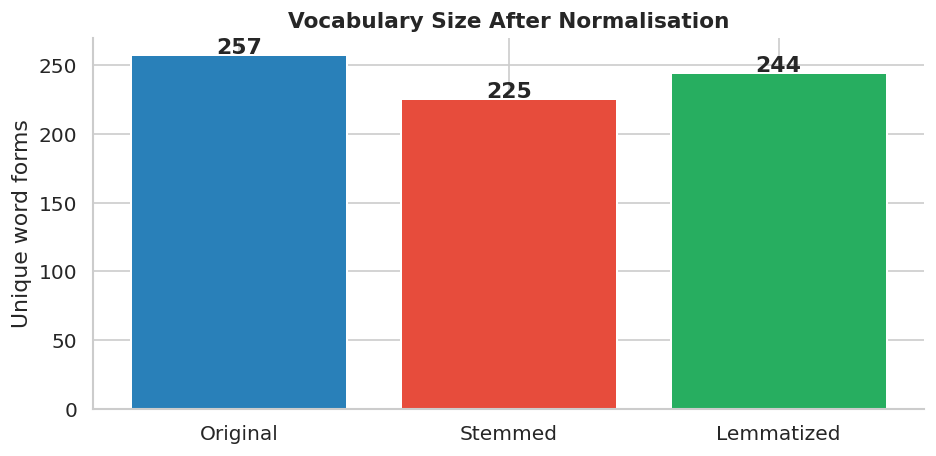


✅ Normalisation complete | stored 599 lemmatised tokens


In [11]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

financial_words = [
    "invest", "investing", "investment", "investments",
    "risk", "risky", "risks", "risking",
    "revenue", "revenues", "financial", "finances",
    "corporate", "corporation", "companies", "company",
    "better", "best", "was", "competing", "competitors", "compete",
]

comparison_df = pd.DataFrame({
    "Original":    financial_words,
    "Stemmed":     [stemmer.stem(w) for w in financial_words],
    "Lemmatized":  [lemmatizer.lemmatize(w, pos='v')
                    if w in {"investing","risking","competing","was","is"}
                    else lemmatizer.lemmatize(w)
                    for w in financial_words],
})
comparison_df["Same as original?"] = comparison_df["Original"] == comparison_df["Lemmatized"]

print("STEMMING vs LEMMATISATION — Financial Vocabulary")
print("=" * 65)
print(comparison_df.to_string(index=False))

# ── Vocabulary reduction analysis ──────────────────────────────────────────────
alpha = [w for w in all_words if w.isalpha()]
stemmed_vocab    = set(stemmer.stem(w) for w in alpha)
lemmatized_vocab = set(lemmatizer.lemmatize(w) for w in alpha)
original_vocab   = set(alpha)

print(f"\nVocabulary reduction on the full 10-K text:")
print(f"  Original tokens (unique) : {len(original_vocab):4d}")
print(f"  After stemming           : {len(stemmed_vocab):4d}  ({(1-len(stemmed_vocab)/len(original_vocab))*100:.1f}% reduction)")
print(f"  After lemmatisation      : {len(lemmatized_vocab):4d}  ({(1-len(lemmatized_vocab)/len(original_vocab))*100:.1f}% reduction)")

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(["Original", "Stemmed", "Lemmatized"],
              [len(original_vocab), len(stemmed_vocab), len(lemmatized_vocab)],
              color=[COLOR_MAIN, COLOR_NEG, COLOR_POS], edgecolor='white', linewidth=1.2)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontweight='bold')
ax.set_title("Vocabulary Size After Normalisation")
ax.set_ylabel("Unique word forms")
sns.despine()
plt.tight_layout()
plt.show()

# Store for downstream use
normalized_words = [lemmatizer.lemmatize(w) for w in all_words if w.isalpha()]
print(f"\n✅ Normalisation complete | stored {len(normalized_words):,} lemmatised tokens")

<a id='4'></a>
## Stop-Word Removal

**Stop words** are high-frequency function words (`the`, `a`, `is`, `and`) that carry no domain-specific signal. Removing them concentrates the model's attention on meaningful content words.

> **Finance twist:** Some standard stop words can matter in financial analysis. For example, `"not"` is usually a stop word — but removing it turns *"we are not profitable"* into *"we are profitable"*. In Section 11 (Sentiment), we'll handle this carefully with **negation-aware** analysis.

BEFORE stop-word removal:
  ['we', 'may', 'not', 'be', 'able', 'to', 'attract', 'and', 'retain', 'customers', 'on', 'a', 'cost-effective', 'basis', '.']  (15 tokens)

AFTER stop-word removal:
  ['may', 'able', 'attract', 'retain', 'customers', 'cost-effective', 'basis']  (7 tokens)

  ⚠️  Note: 'not' was removed — this changes meaning!
  Solution: keep negations or use negation-aware sentiment (see Section 11).

──────────────────────────────────────────────────
  Full text — original tokens : 666
  After stop-word removal     : 357
  Reduction                   : 46.4%

Top 15 meaningful words:
       Word  Count  % of meaningful tokens
       risk     16                    4.48
  customers     11                    3.08
      could      9                    2.52
   business      7                    1.96
        may      7                    1.96
   products      6                    1.68
        new      5                    1.40
     search      5                    1.40
   service

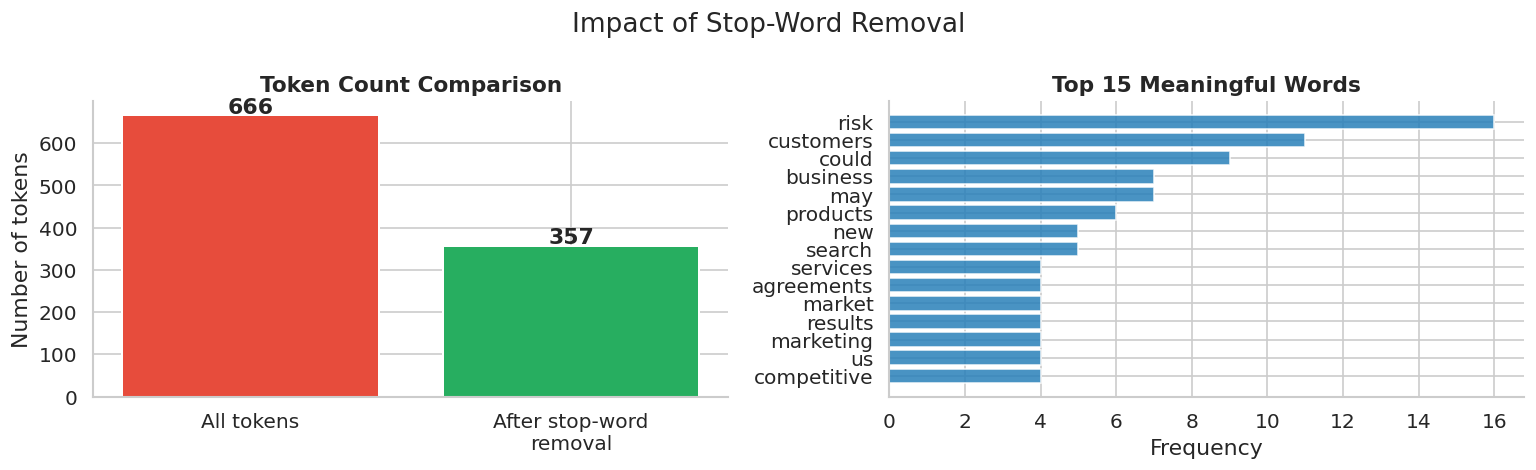


✅ Stop-word removal complete


In [12]:
stop_words = set(stopwords.words('english'))

# ── Before / after on one sentence ────────────────────────────────────────────
sample = "We may not be able to attract and retain customers on a cost-effective basis."
before = word_tokenize(sample.lower())
after  = [w for w in before if w not in stop_words and w not in string.punctuation]

print("BEFORE stop-word removal:")
print(f"  {before}  ({len(before)} tokens)")
print("\nAFTER stop-word removal:")
print(f"  {after}  ({len(after)} tokens)")
print(f"\n  ⚠️  Note: 'not' was removed — this changes meaning!")
print(f"  Solution: keep negations or use negation-aware sentiment (see Section 11).")

# ── Apply to full text ─────────────────────────────────────────────────────────
cleaned_words = [w for w in all_words
                 if w not in stop_words and w not in string.punctuation and w.isalpha()]

pct_removed = (1 - len(cleaned_words) / len(all_words)) * 100
print(f"\n{'─'*50}")
print(f"  Full text — original tokens : {len(all_words):,}")
print(f"  After stop-word removal     : {len(cleaned_words):,}")
print(f"  Reduction                   : {pct_removed:.1f}%")

# Top meaningful words
top15 = Counter(cleaned_words).most_common(15)
top15_df = pd.DataFrame(top15, columns=["Word", "Count"])
top15_df["% of meaningful tokens"] = (top15_df["Count"] / len(cleaned_words) * 100).round(2)

print(f"\nTop 15 meaningful words:")
print(top15_df.to_string(index=False))

# ── Visualise the stop-word effect ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Impact of Stop-Word Removal")

categories = ["All tokens", "After stop-word\nremoval"]
counts     = [len(all_words), len(cleaned_words)]
colors     = [COLOR_NEG, COLOR_POS]
axes[0].bar(categories, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Token Count Comparison")
axes[0].set_ylabel("Number of tokens")
for i, (c, v) in enumerate(zip(categories, counts)):
    axes[0].text(i, v + 5, f"{v:,}", ha='center', fontweight='bold')

words_top, counts_top = zip(*top15)
axes[1].barh(list(words_top), list(counts_top), color=COLOR_MAIN, edgecolor='white', alpha=0.85)
axes[1].set_title("Top 15 Meaningful Words")
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

print("\n✅ Stop-word removal complete")

## Word Frequency Analysis

**Word frequency** is the simplest quantitative signal in NLP, yet it carries real predictive power in finance.

Academic research (Loughran & McDonald, 2011) shows that the **frequency of negative words** in 10-K filings predicts abnormal stock returns and trading volume in the week following the filing. Frequency alone — no machine learning needed.

Key use cases:
- Track how often "risk" appears year-over-year in the same company's filings
- Compare competitors: does Company A obsess over "regulation" while Company B obsesses over "competition"?
- Build a quick risk-score heuristic: `risk_score = count("risk") / total_words`

TOP 20 WORDS — 10-K Risk Section
       Word  Frequency  % of corpus  Cumulative %
       risk         16         4.48          4.48
  customers         11         3.08          7.56
      could          9         2.52         10.08
   business          7         1.96         12.04
        may          7         1.96         14.00
   products          6         1.68         15.68
        new          5         1.40         17.08
     search          5         1.40         18.48
   services          4         1.12         19.60
 agreements          4         1.12         20.72
     market          4         1.12         21.84
    results          4         1.12         22.96
  marketing          4         1.12         24.08
         us          4         1.12         25.20
competitive          4         1.12         26.32
      renew          3         0.84         27.16
   revenues          3         0.84         28.00
    decline          3         0.84         28.84
       able      

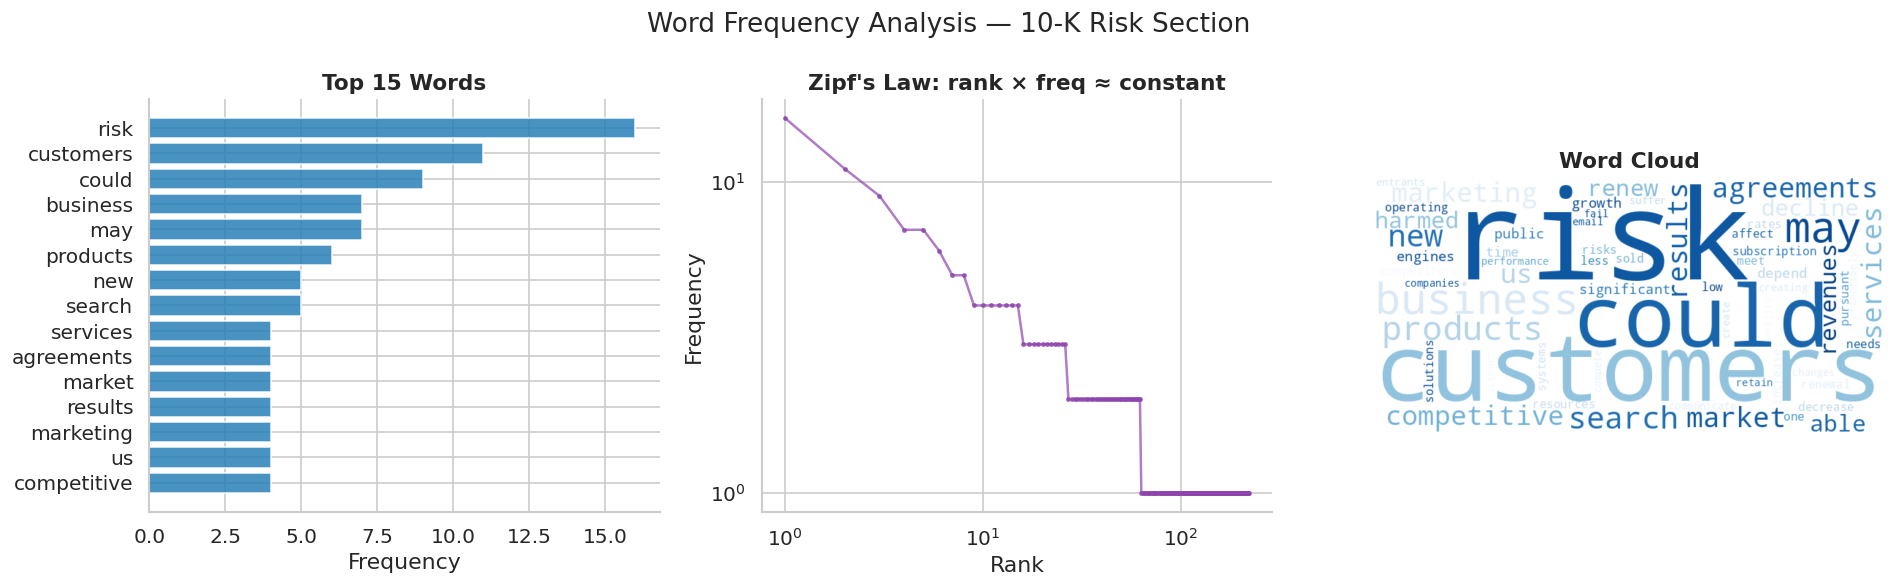


📊 Quick risk-score (proportion of 'risk' in corpus): 0.045
   Industry benchmark: >0.020 is considered high for tech companies.

✅ Frequency analysis complete


In [13]:
word_freq = Counter(cleaned_words)

# ── Frequency table ────────────────────────────────────────────────────────────
top20_df = pd.DataFrame(word_freq.most_common(20), columns=["Word", "Frequency"])
top20_df["% of corpus"] = (top20_df["Frequency"] / len(cleaned_words) * 100).round(2)
top20_df["Cumulative %"] = top20_df["% of corpus"].cumsum().round(2)

print("TOP 20 WORDS — 10-K Risk Section")
print("=" * 50)
print(top20_df.to_string(index=False))

# ── Key financial keyword tracker ─────────────────────────────────────────────
keywords = {
    "risk": "Core risk indicator",
    "customer": "Customer-concentration exposure",
    "revenue": "Revenue uncertainty",
    "competitor": "Competitive threat",
    "decline": "Downside language",
    "fail": "Failure language",
    "market": "Market risk",
    "business": "Business operations",
}
print("\nFINANCIAL KEYWORD FREQUENCY TRACKER:")
print("-" * 55)
for kw, desc in keywords.items():
    cnt = word_freq.get(kw, 0)
    bar = "▓" * cnt
    print(f"  {kw:<15} {cnt:3d}×  {bar}  — {desc}")

# ── Zipf's law — do financial texts follow it? ────────────────────────────────
ranks  = np.arange(1, len(word_freq) + 1)
freqs  = [f for _, f in word_freq.most_common()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Word Frequency Analysis — 10-K Risk Section")

# Bar chart
top_n = 15
words_bar, counts_bar = zip(*word_freq.most_common(top_n))
axes[0].barh(list(words_bar), list(counts_bar), color=COLOR_MAIN, edgecolor='white', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title(f"Top {top_n} Words")
axes[0].set_xlabel("Frequency")

# Zipf's law log-log
axes[1].loglog(ranks, freqs, marker='.', linestyle='-', color="#8e44ad", alpha=0.7, markersize=4)
axes[1].set_title("Zipf's Law (log-log)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Zipf's Law: rank × freq ≈ constant")

# Word cloud
wc = WordCloud(width=700, height=350, background_color='white',
               colormap='Blues', max_words=60,
               contour_width=1, contour_color='steelblue').generate_from_frequencies(word_freq)
axes[2].imshow(wc, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title("Word Cloud")

sns.despine()
plt.tight_layout()
plt.show()

risk_score = word_freq.get('risk', 0) / len(cleaned_words)
print(f"\n📊 Quick risk-score (proportion of 'risk' in corpus): {risk_score:.3f}")
print("   Industry benchmark: >0.020 is considered high for tech companies.")
print("\n✅ Frequency analysis complete")

## N-grams & Collocations

Single words lose context. **"Material"** could refer to fabric. **"Material weakness"** is an accounting term signalling internal control failures that can move stock prices.

N-grams capture these multi-word units:

| N | Name | Finance example |
|---|------|----------------|
| 1 | Unigram | `"revenue"` |
| 2 | Bigram | `"revenue decline"`, `"market risk"` |
| 3 | Trigram | `"not be able"`, `"may adversely affect"` |

**Collocations** go further — they filter for word pairs that appear together *more often than chance*, surfacing genuine domain terms rather than random adjacency.

TOP 12 BIGRAMS:
---------------------------------------------
  products services                     4×
  search engines                        3×
  services sold                         2×
  sold pursuant                         2×
  pursuant subscription                 2×
  subscription agreements               2×
  renew agreements                      2×
  revenues may                          2×
  may decrease                          2×
  renewal rates                         2×
  may able                              2×
  meet customers                        2×

TOP 8 TRIGRAMS:
-------------------------------------------------------
  products services sold                          2×
  services sold pursuant                          2×
  sold pursuant subscription                      2×
  pursuant subscription agreements                2×
  revenues may decrease                           2×
  operating results could                         2×
  results could harmed         

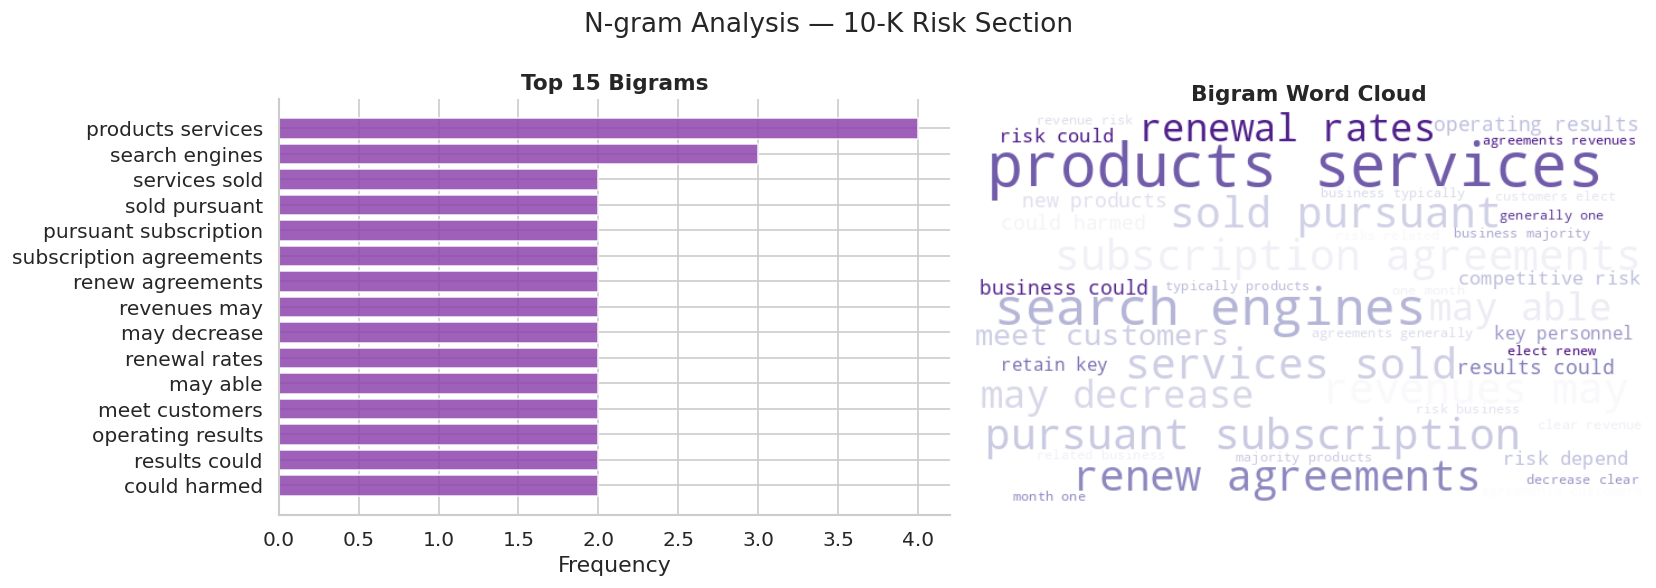


💡 Phrases like 'may decline', 'operating results', 'could harmed' are
   hedging / downside language — hallmarks of risk-factor prose.

✅ N-gram analysis complete


In [14]:
# ── Manual N-gram extraction ──────────────────────────────────────────────────
def extract_ngrams(tokens, n):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

bigrams_raw  = extract_ngrams(cleaned_words, 2)
trigrams_raw = extract_ngrams(cleaned_words, 3)

bigram_freq  = Counter(bigrams_raw)
trigram_freq = Counter(trigrams_raw)

print("TOP 12 BIGRAMS:")
print("-" * 45)
for phrase, cnt in bigram_freq.most_common(12):
    print(f"  {phrase:<35} {cnt:3d}×")

print("\nTOP 8 TRIGRAMS:")
print("-" * 55)
for phrase, cnt in trigram_freq.most_common(8):
    print(f"  {phrase:<45} {cnt:3d}×")

# ── Statistical collocations (PMI) ────────────────────────────────────────────
print("\nSTATISTICAL COLLOCATIONS (PMI score — word pairs that co-occur by more than chance):")
print("-" * 65)

bigram_finder = BigramCollocationFinder.from_words(cleaned_words)
bigram_finder.apply_freq_filter(2)
pmi_bigrams = bigram_finder.nbest(BigramAssocMeasures.pmi, 10)
for pair in pmi_bigrams:
    print(f"  {pair[0]:20} + {pair[1]:20}")

# ── Visualise bigram frequencies ──────────────────────────────────────────────
top_bigrams = dict(bigram_freq.most_common(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("N-gram Analysis — 10-K Risk Section")

words_bg, counts_bg = zip(*list(top_bigrams.items()))
axes[0].barh(list(words_bg), list(counts_bg), color="#8e44ad", edgecolor='white', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Bigrams")
axes[0].set_xlabel("Frequency")

# Word cloud of bigrams
wc_bg = WordCloud(width=600, height=350, background_color='white',
                  colormap='Purples', max_words=40).generate_from_frequencies(bigram_freq)
axes[1].imshow(wc_bg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Bigram Word Cloud")

sns.despine()
plt.tight_layout()
plt.show()

print("\n💡 Phrases like 'may decline', 'operating results', 'could harmed' are")
print("   hedging / downside language — hallmarks of risk-factor prose.")
print("\n✅ N-gram analysis complete")

## Part-of-Speech Tagging

POS tagging assigns a grammatical label to each token. Why does this matter for finance?

| POS | Tag | Financial use |
|-----|-----|--------------|
| Noun (NN/NNS) | Entity names | Extract "HubSpot", "revenue", "SEC" |
| Verb (VB/VBZ) | Actions / events | "declined", "breached", "failed" |
| Adjective (JJ) | Risk severity | "material", "significant", "adverse" |
| Modal (MD) | Uncertainty | "may", "could", "might" — hedging language |

Modal verbs are especially interesting: *"revenue may decline"* is a weaker disclosure than *"revenue will decline"*. POS tagging lets you count hedge words programmatically.

EXAMPLE — POS tags for two financial sentences:

  Sentence: Our revenue may decline if competitors offer better products.
    Our                    → PRP$     (Poss.Pronoun)
    revenue                → NN       (Noun)
    may                    → MD       (Modal)
    decline                → VB       (Verb)
    if                     → IN       (Preposition)
    competitors            → NNS      (Noun(pl))
    offer                  → VBP      (Verb(pres))
    better                 → JJR      (Adj(comp))
    products               → NNS      (Noun(pl))
    .                      → .        (.)

  Sentence: Material weaknesses in internal controls could harm investors.
    Material               → JJ       (Adjective)
    weaknesses             → NNS      (Noun(pl))
    in                     → IN       (Preposition)
    internal               → JJ       (Adjective)
    controls               → NNS      (Noun(pl))
    could                  → MD       (Modal)
    harm               

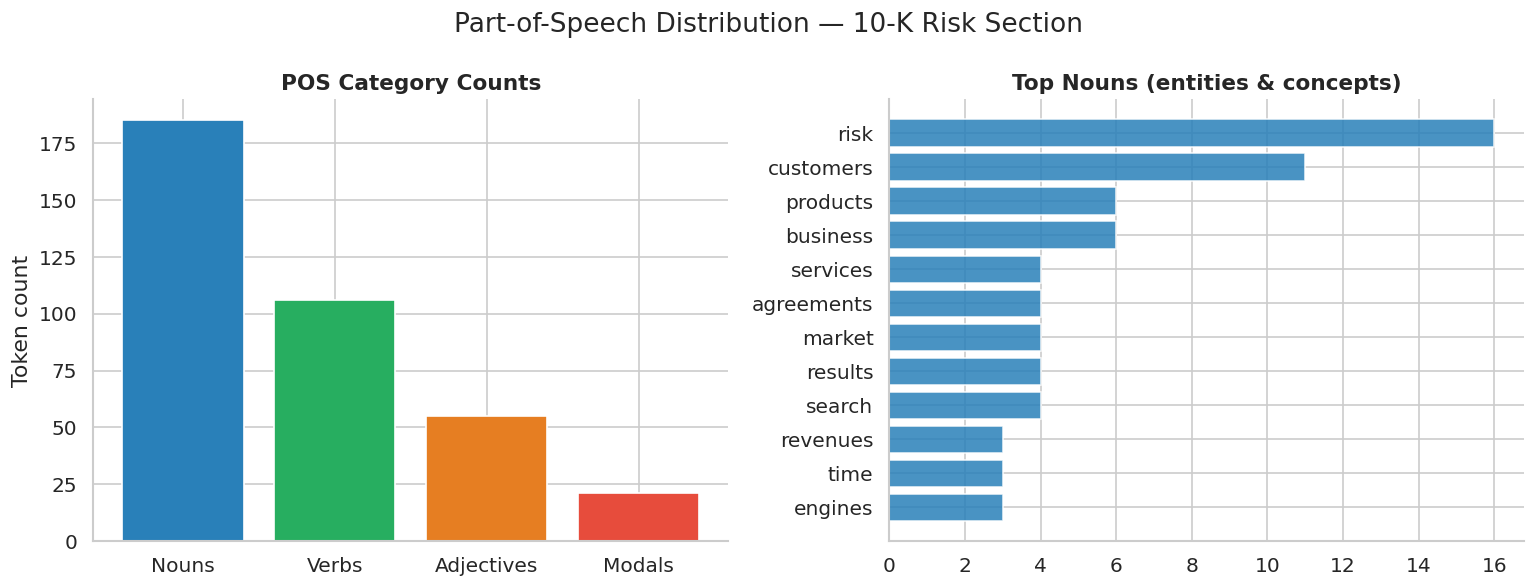


✅ POS tagging complete


In [15]:
# ── Tag the full text ─────────────────────────────────────────────────────────
pos_tagged = pos_tag(word_tokenize(financial_text))

# Friendly tag map
TAG_MAP = {
    'NN':'Noun','NNS':'Noun(pl)','NNP':'Proper Noun','NNPS':'Proper Noun(pl)',
    'VB':'Verb','VBD':'Verb(past)','VBG':'Verb(gerund)','VBZ':'Verb(3rd)','VBN':'Verb(past part)','VBP':'Verb(pres)',
    'JJ':'Adjective','JJR':'Adj(comp)','JJS':'Adj(super)',
    'RB':'Adverb','IN':'Preposition','DT':'Determiner',
    'MD':'Modal','CC':'Conjunction','PRP':'Pronoun','PRP$':'Poss.Pronoun','CD':'Number',
}

# ── Example sentence tagging ──────────────────────────────────────────────────
print("EXAMPLE — POS tags for two financial sentences:")
print("=" * 65)
for sent_text in [
    "Our revenue may decline if competitors offer better products.",
    "Material weaknesses in internal controls could harm investors.",
]:
    print(f"\n  Sentence: {sent_text}")
    tokens = word_tokenize(sent_text)
    tags   = pos_tag(tokens)
    for w, t in tags:
        print(f"    {w:<22} → {t:<8} ({TAG_MAP.get(t, t)})")

# ── Extract POS categories from the full text ──────────────────────────────────
nouns      = [w for w, t in pos_tagged if t.startswith('NN')]
verbs      = [w for w, t in pos_tagged if t.startswith('VB')]
adjectives = [w for w, t in pos_tagged if t.startswith('JJ')]
modals     = [w for w, t in pos_tagged if t == 'MD']

pos_summary = pd.DataFrame({
    "POS": ["Nouns", "Verbs", "Adjectives", "Modal Verbs"],
    "Count": [len(nouns), len(verbs), len(adjectives), len(modals)],
    "Top Examples": [
        ', '.join([w for w, _ in Counter(nouns).most_common(5)]),
        ', '.join([w for w, _ in Counter(verbs).most_common(5)]),
        ', '.join([w for w, _ in Counter(adjectives).most_common(5)]),
        ', '.join(set(modals)),
    ]
})
print("\nPOS SUMMARY — 10-K Risk Section:")
print(pos_summary.to_string(index=False))

modal_count = len(modals)
total_words = len([w for w, t in pos_tagged if w.isalpha()])
print(f"\n📊 Hedge-word density (modals / alpha tokens): {modal_count}/{total_words} = {modal_count/total_words:.3f}")
print("   High hedge density is typical of Risk Factor sections.")

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part-of-Speech Distribution — 10-K Risk Section")

pos_groups = {"Nouns": nouns, "Verbs": verbs, "Adjectives": adjectives, "Modals": modals}
axes[0].bar(pos_groups.keys(), [len(v) for v in pos_groups.values()],
            color=[COLOR_MAIN, COLOR_POS, COLOR_UNC, COLOR_NEG], edgecolor='white')
axes[0].set_title("POS Category Counts")
axes[0].set_ylabel("Token count")

# Top nouns
top_nouns = dict(Counter(nouns).most_common(12))
axes[1].barh(list(top_nouns.keys()), list(top_nouns.values()), color=COLOR_MAIN, edgecolor='white', alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title("Top Nouns (entities & concepts)")

sns.despine()
plt.tight_layout()
plt.show()
print("\n✅ POS tagging complete")

## Bag-of-Words & TF-IDF

To feed text into machine-learning models we must convert it into numbers. Two classic approaches:

**Bag-of-Words (BoW)** — count how many times each word appears in a document. Simple, but gives equal weight to common and rare words.

**TF-IDF** (Term Frequency × Inverse Document Frequency) — down-weights words that appear in many documents (like "the") and up-weights words unique to a specific document. It answers: *what makes this 10-K different from all others?*

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t, d)}{\text{words in } d}}_{\text{TF}} \times \underbrace{\log \frac{N}{1 + \text{docs containing } t}}_{\text{IDF}}$$

BAG-OF-WORDS MATRIX (non-zero terms):
                achieve  acquisition  algorithm  anticipated  attract  base  business  cause  changes  competitors  consolidation  customer  customers  decline  depend  engines  entrants  face  fail  growth  key  new  personnel  pose  rates  renewal  retain  revenues  risk  search  significant  suffer  technologies  threats
Risk Section 1        0            0          0            0        0     0         0      1        0            0              0         0          0        1       0        0         1     1     0       0    0    1          0     0      0        0       0         1     0       0            1       1             0        1
Risk Section 2        0            0          0            0        0     1         0      0        0            1              1         1          0        1       0        0         0     0     0       0    0    1          0     0      1        1       0         0     0       0            0       0        

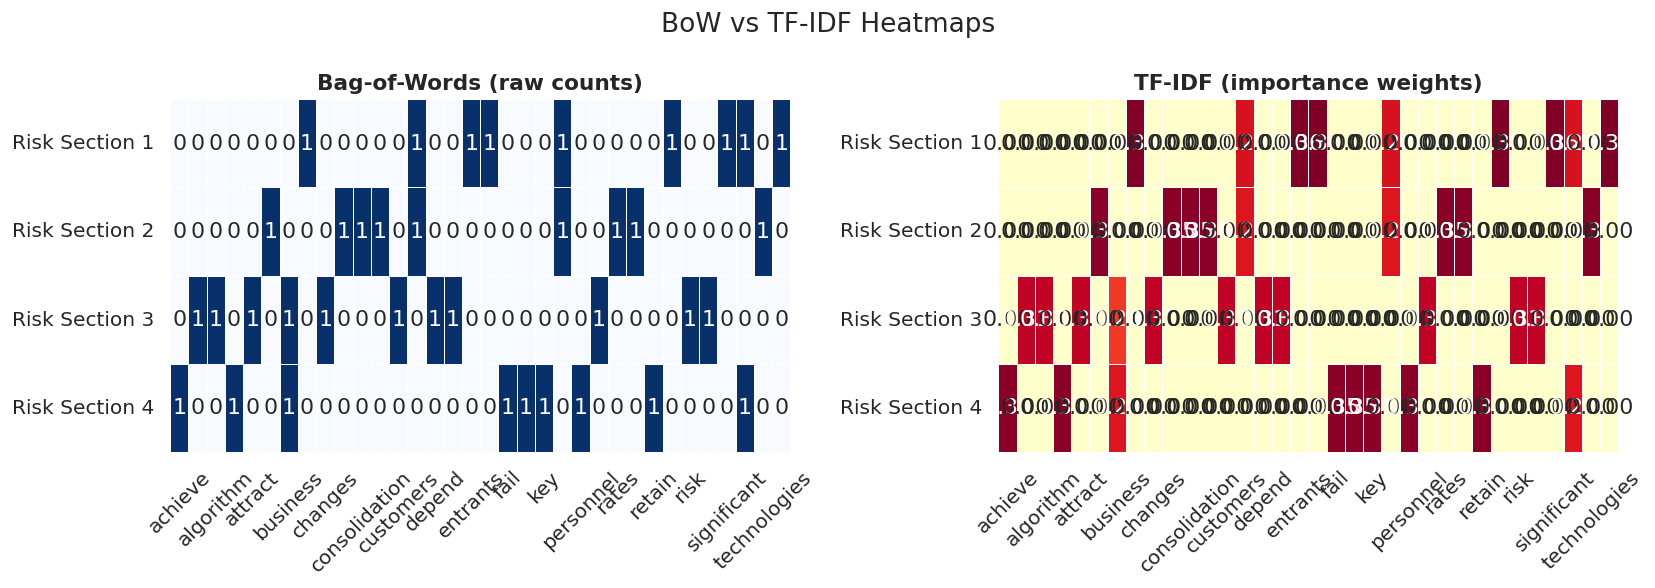


✅ BoW & TF-IDF complete


In [16]:
sections = [
    "We face significant threats from new entrants which could cause us to suffer a decline in revenues",
    "Our renewal rates may decline due to competitors new technologies and consolidation in our customer base",
    "We depend on search engines to attract customers and algorithm changes pose acquisition risk to our business",
    "If we fail to retain key personnel we may not achieve anticipated growth and our business could suffer",
]
section_names = [f"Risk Section {i+1}" for i in range(len(sections))]

# ── BoW ────────────────────────────────────────────────────────────────────────
cv  = CountVectorizer(max_features=40, stop_words='english')
bow = cv.fit_transform(sections)
bow_df = pd.DataFrame(bow.toarray(), columns=cv.get_feature_names_out(), index=section_names)
# Show only non-zero columns
nz = bow_df.columns[bow_df.sum() > 0]
print("BAG-OF-WORDS MATRIX (non-zero terms):")
print(bow_df[nz].to_string())

# ── TF-IDF ─────────────────────────────────────────────────────────────────────
tv     = TfidfVectorizer(max_features=40, stop_words='english')
tfidf  = tv.fit_transform(sections)
tfidf_df = pd.DataFrame(tfidf.toarray().round(3), columns=tv.get_feature_names_out(), index=section_names)
nz_t   = tfidf_df.columns[(tfidf_df > 0).any()]

print("\nTF-IDF MATRIX (non-zero terms):")
print(tfidf_df[nz_t].to_string())

# ── Key difference illustration ────────────────────────────────────────────────
print("\n💡 Compare 'decline' vs a term unique to one section:")
shared_term = "decline"
if shared_term in bow_df.columns:
    print(f"  BoW   'decline' : {list(bow_df[shared_term])}")
    print(f"  TF-IDF 'decline': {list(tfidf_df[shared_term].round(3))}")
    print(f"  → TF-IDF is lower because 'decline' appears in multiple sections.")

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BoW vs TF-IDF Heatmaps")

# BoW heatmap
sns.heatmap(bow_df[nz], ax=axes[0], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar=False)
axes[0].set_title("Bag-of-Words (raw counts)")
axes[0].tick_params(axis='x', rotation=45)

# TF-IDF heatmap
sns.heatmap(tfidf_df[nz_t], ax=axes[1], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar=False)
axes[1].set_title("TF-IDF (importance weights)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("\n✅ BoW & TF-IDF complete")

## Document Similarity

Once documents are represented as TF-IDF vectors, **cosine similarity** measures how closely two documents point in the same direction through the high-dimensional vocabulary space.

$$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}||\vec{B}|}$$

Values range from 0 (nothing in common) to 1 (identical). This has direct applications:
- **Peer group analysis** — cluster companies by risk-factor similarity
- **Plagiarism detection** — identify companies copying boilerplate disclosures
- **Year-over-year change** — a company's disclosure diverging from itself can signal a major strategic shift

COSINE SIMILARITY MATRIX:
                      TechCo A (SaaS)  TechCo B (similar)  RetailCo (different)  New Filing (unknown)
TechCo A (SaaS)                 1.000               0.204                 0.000                 0.103
TechCo B (similar)              0.204               1.000                 0.078                 0.191
RetailCo (different)            0.000               0.078                 1.000                 0.000
New Filing (unknown)            0.103               0.191                 0.000                 1.000

📌 'New Filing (unknown)' — closest peers:
  TechCo B (similar)        0.191  █████
  TechCo A (SaaS)           0.103  ███
  RetailCo (different)      0.000  


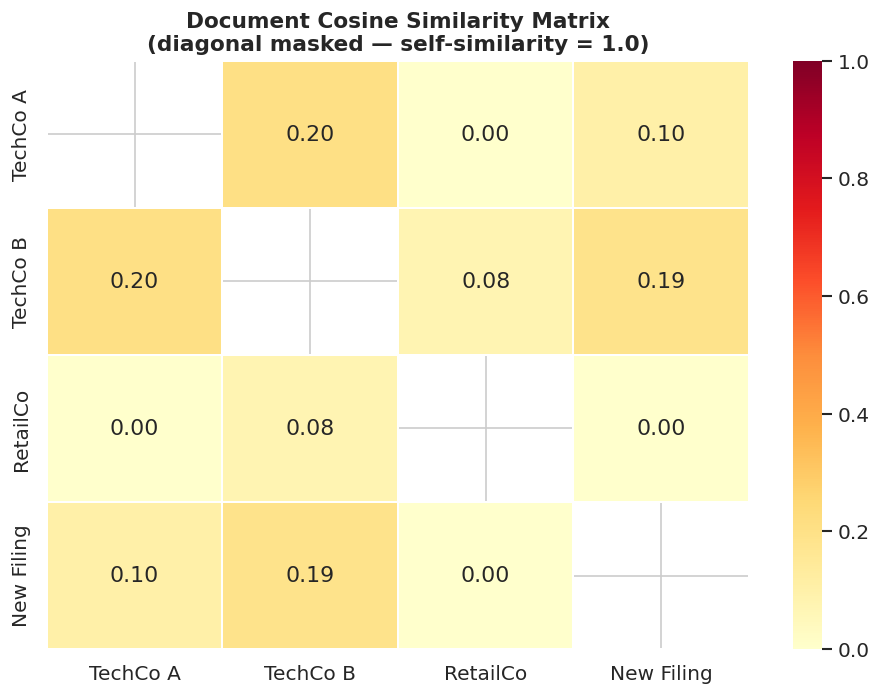


✅ Document similarity complete


In [17]:
# ── Four simulated company risk excerpts ──────────────────────────────────────
docs = {
    "TechCo A (SaaS)":       "We face risks from competition market decline and customer attrition in subscription software",
    "TechCo B (similar)":    "Competition and declining markets threaten our subscription customer base and SaaS revenue",
    "RetailCo (different)":  "Supply chain disruption and inventory management risk threaten our retail margins and logistics",
    "New Filing (unknown)":  "Our SaaS business depends on customer retention and faces strong competition from new entrants",
}

doc_names = list(docs.keys())
doc_texts = list(docs.values())

# ── TF-IDF + cosine similarity ────────────────────────────────────────────────
tv_all = TfidfVectorizer(stop_words='english')
matrix = tv_all.fit_transform(doc_texts)
sim    = cosine_similarity(matrix)

sim_df = pd.DataFrame(sim, index=doc_names, columns=doc_names)
print("COSINE SIMILARITY MATRIX:")
print(sim_df.round(3).to_string())

# ── Most similar peer ──────────────────────────────────────────────────────────
target_idx = doc_names.index("New Filing (unknown)")
sims_to_target = [(doc_names[i], sim[target_idx][i])
                  for i in range(len(doc_names)) if i != target_idx]
sims_to_target.sort(key=lambda x: x[1], reverse=True)

print("\n📌 'New Filing (unknown)' — closest peers:")
for name, score in sims_to_target:
    bar = "█" * int(score * 30)
    print(f"  {name:<25} {score:.3f}  {bar}")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(len(sim_df), dtype=bool)   # mask diagonal
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=1, linecolor='white', ax=ax,
            vmin=0, vmax=1, mask=mask,
            xticklabels=[n.split("(")[0].strip() for n in doc_names],
            yticklabels=[n.split("(")[0].strip() for n in doc_names])
ax.set_title("Document Cosine Similarity Matrix\n(diagonal masked — self-similarity = 1.0)")
plt.tight_layout()
plt.show()

print("\n✅ Document similarity complete")

## Readability Indices

**Readability indices** quantify how complex a text is, based on sentence length and word syllable count.

| Index | Scale | Interpretation |
|-------|-------|----------------|
| Flesch-Kincaid Grade | 0–18+ | U.S. school grade needed to understand |
| Gunning Fog | 0–18+ | Years of formal education needed |
| Flesch Reading Ease | 0–100 | Higher = easier (inverted from above) |

**Why this matters for finance — the fog factor:**  
A landmark study (Li, 2008) showed that companies with *more complex* annual reports had *worse future earnings*, and that complexity increased when managers were obscuring bad news. The SEC now explicitly monitors for "plain English" violations in disclosures.

A one-point increase in Fog Index has been shown to correspond to a measurable decline in market liquidity (reduced trading) due to investor confusion.

READABILITY ANALYSIS:
       Document  FK Grade  Fog Index  Reading Ease  Avg sent. len.  Avg word len.         Level
 Simple (clear)       3.0        8.0          89.6            10.0           3.89 Middle School
Complex (foggy)      26.8       30.1         -49.3            28.0           7.65      College+
    Actual 10-K      16.5       20.0          23.7            29.0           5.35      College+

Actual 10-K readability verdict: ⚠️  College-level — potentially obfuscated or legally complex


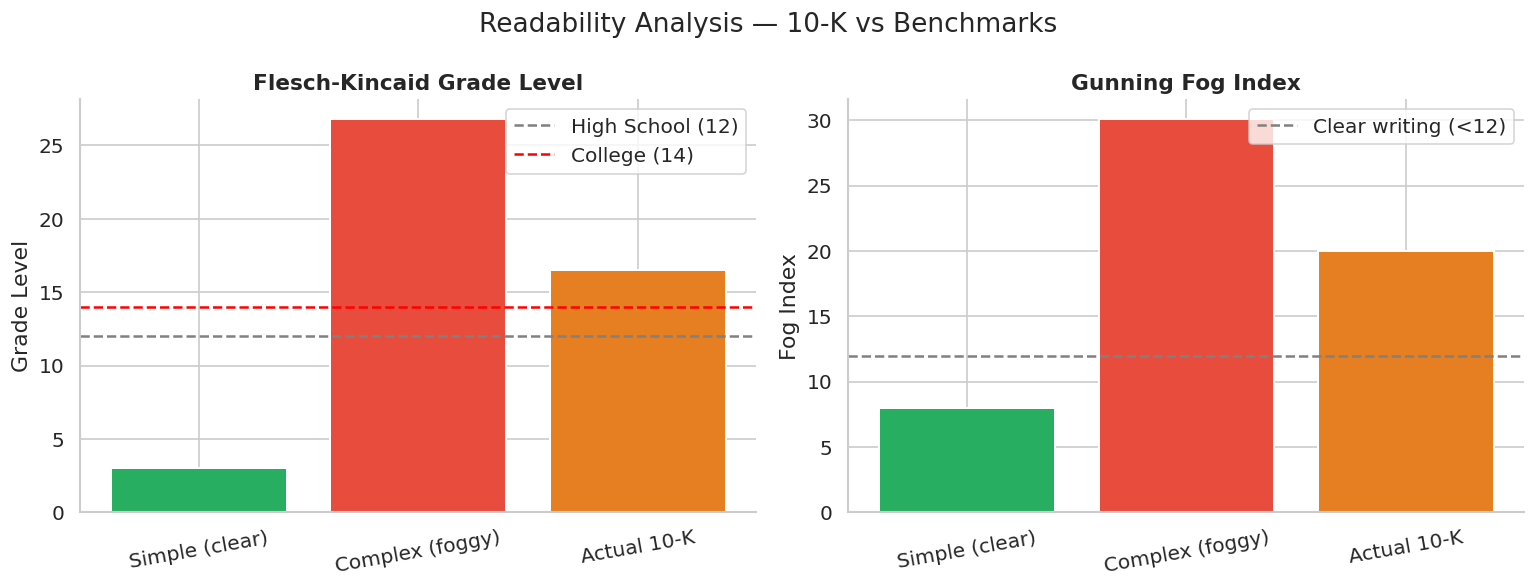


✅ Readability analysis complete


In [18]:
simple_text  = "We may lose customers if we do not serve them well. We work hard to keep customers happy."
complex_text = ("The potential diminution of our customer base arising from insufficient service delivery quality "
                "necessitates comprehensive strategic initiatives to maintain customer satisfaction metrics and "
                "enhance long-term retention sustainability.")
texts = {
    "Simple (clear)":   simple_text,
    "Complex (foggy)":  complex_text,
    "Actual 10-K":      financial_text,
}

rows = []
for name, text in texts.items():
    fk   = textstat.flesch_kincaid_grade(text)
    fog  = textstat.gunning_fog(text)
    ease = textstat.flesch_reading_ease(text)
    asl  = len(word_tokenize(text)) / max(len(sent_tokenize(text)), 1)
    awl  = np.mean([len(w) for w in word_tokenize(text) if w.isalpha()])
    rows.append({"Document": name,
                 "FK Grade": round(fk,1), "Fog Index": round(fog,1),
                 "Reading Ease": round(ease,1),
                 "Avg sent. len.": round(asl,1), "Avg word len.": round(awl,2),
                 "Level": "College+" if fk>14 else "High School" if fk>10 else "Middle School"})

read_df = pd.DataFrame(rows)
print("READABILITY ANALYSIS:")
print(read_df.to_string(index=False))

# Interpretation of actual 10-K
fk_actual = read_df.loc[read_df["Document"]=="Actual 10-K","FK Grade"].values[0]
if fk_actual > 14:
    verdict = "⚠️  College-level — potentially obfuscated or legally complex"
elif fk_actual > 11:
    verdict = "📝 High school level — fairly typical for corporate disclosures"
else:
    verdict = "✅ Clear and accessible — good transparency signal"
print(f"\nActual 10-K readability verdict: {verdict}")

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Readability Analysis — 10-K vs Benchmarks")

colors_bar = [COLOR_POS, COLOR_NEG, COLOR_UNC]
axes[0].bar(read_df["Document"], read_df["FK Grade"], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].axhline(12, color='gray', linestyle='--', label='High School (12)')
axes[0].axhline(14, color='red',  linestyle='--', label='College (14)')
axes[0].set_title("Flesch-Kincaid Grade Level")
axes[0].set_ylabel("Grade Level")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(read_df["Document"], read_df["Fog Index"], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[1].axhline(12, color='gray', linestyle='--', label='Clear writing (<12)')
axes[1].set_title("Gunning Fog Index")
axes[1].set_ylabel("Fog Index")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=10)

sns.despine()
plt.tight_layout()
plt.show()
print("\n✅ Readability analysis complete")

## Sentiment Analysis

Sentiment analysis in finance is fundamentally different from general NLP. Standard VADER or TextBlob dictionaries were trained on movie reviews — they misclassify words like **"liability"** (neutral in law, negative in everyday speech) or **"capital"** (positive for growth, negative in "capital loss").

**The Loughran-McDonald (LM) Master Dictionary** was built specifically for financial filings. It categorises words into:
- Negative, Positive, Uncertainty, Litigious, Constraining, Superfluous

We implement a subset below. In production, download the full LM dictionary from [here](https://sraf.nd.edu/loughranmcdonald-master-dictionary/).

**Negation-aware analysis:** We also check for "not + positive" patterns (e.g. *"not profitable"*) — something standard dictionaries miss entirely.

SENTIMENT ANALYSIS — Actual 10-K Risk Section
  Positive words        :   7  (10.1%)
  Negative words        :  35  (50.7%)
  Uncertainty words     :  26  (37.7%)
  Litigious words       :   1
  Negated positives     :   1  (e.g. 'not effective')
  Net sentiment score   : -0.406  (+ = positive, − = negative)

COMPARATIVE SENTIMENT:
        Text  Positive%  Negative%  Uncertain%  Net score
Bullish MD&A      100.0        0.0         0.0      1.000
Bearish 10-K        0.0       50.0        50.0     -0.500
 Actual 10-K       10.1       50.7        37.7     -0.406


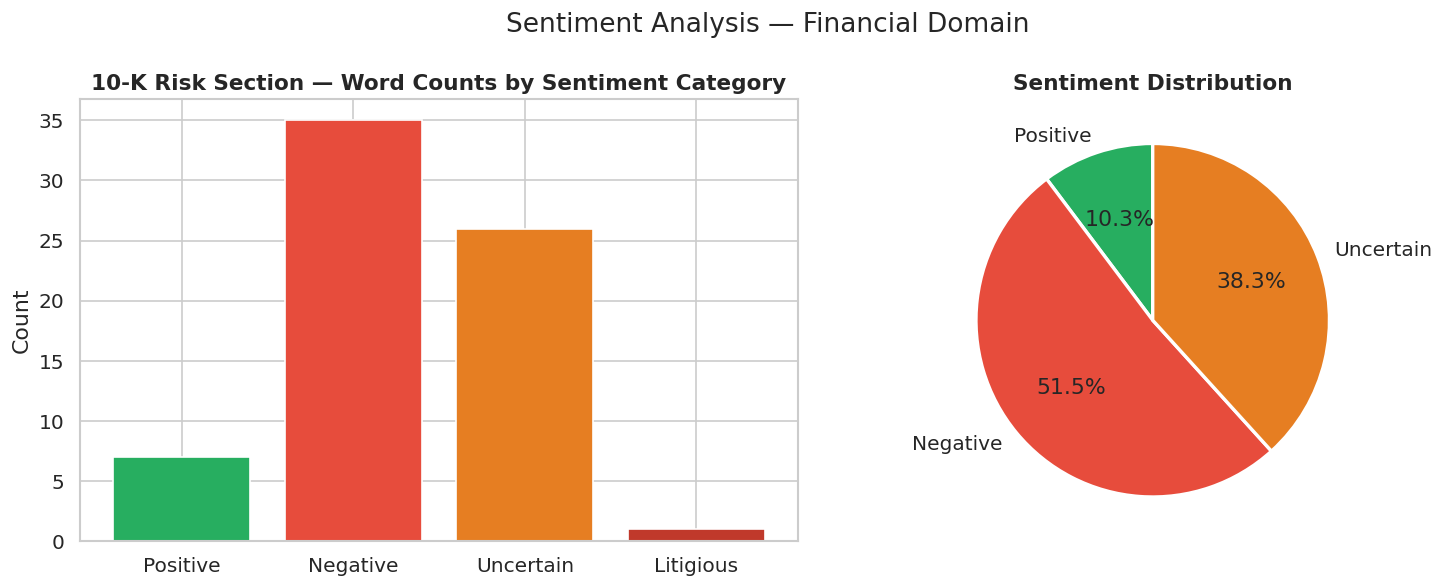


✅ Sentiment analysis complete


In [19]:
# ── Financial-domain sentiment dictionaries (Loughran-McDonald inspired) ──────
POSITIVE_WORDS = {
    'gain','growth','strong','improved','success','opportunity','leading',
    'innovation','efficient','benefit','profit','profitable','excellence',
    'grow','increase','expand','improve','achieve','effective',
}
NEGATIVE_WORDS = {
    'loss','decline','risk','uncertain','fail','failure','challenge',
    'difficult','adverse','adversely','weak','weakness','threat','unable',
    'harm','harmful','decline','decrease','decline','harms','harmed',
    'suffer','suffers','suffering','expose','exposing','obsolete',
    'strain','impede','impair','deteriorate','worsen',
}
UNCERTAIN_WORDS = {
    'may','might','could','potential','potentially','uncertain','unknown',
    'fluctuate','volatile','approximately','estimate','if','whether',
}
LITIGIOUS_WORDS = {
    'lawsuit','litigation','claims','breach','liable','indemnify',
    'regulatory','compliance','enforcement','penalty','legal',
}

def analyze_sentiment_financial(text, window=3):
    """
    Sentiment analysis with:
    - domain-specific word lists
    - negation window (checks for 'not/no/never' within `window` tokens before a positive word)
    """
    tokens = [w.lower() for w in word_tokenize(text)]
    NEGATORS = {'not', 'no', 'never', 'neither', 'nor', 'without'}

    pos, neg, unc, lit, negated_pos = 0, 0, 0, 0, 0
    for i, w in enumerate(tokens):
        start = max(0, i - window)
        preceding = set(tokens[start:i])
        negated   = bool(preceding & NEGATORS)

        if w in POSITIVE_WORDS:
            if negated:
                negated_pos += 1
                neg += 1          # "not profitable" → negative
            else:
                pos += 1
        elif w in NEGATIVE_WORDS:
            neg += 1
        elif w in UNCERTAIN_WORDS:
            unc += 1
        elif w in LITIGIOUS_WORDS:
            lit += 1

    total = pos + neg + unc + lit
    return {"positive": pos, "negative": neg, "uncertain": unc,
            "litigious": lit, "negated_positive": negated_pos,
            "total_sentiment_words": total,
            "pos_pct": round(pos/total*100,1) if total else 0,
            "neg_pct": round(neg/total*100,1) if total else 0,
            "unc_pct": round(unc/total*100,1) if total else 0,
            "net_score": round((pos-neg)/max(total,1), 3)}

# ── Analyse the 10-K text ──────────────────────────────────────────────────────
result = analyze_sentiment_financial(financial_text)

print("SENTIMENT ANALYSIS — Actual 10-K Risk Section")
print("=" * 55)
print(f"  Positive words        : {result['positive']:3d}  ({result['pos_pct']}%)")
print(f"  Negative words        : {result['negative']:3d}  ({result['neg_pct']}%)")
print(f"  Uncertainty words     : {result['uncertain']:3d}  ({result['unc_pct']}%)")
print(f"  Litigious words       : {result['litigious']:3d}")
print(f"  Negated positives     : {result['negated_positive']:3d}  (e.g. 'not effective')")
print(f"  Net sentiment score   : {result['net_score']:+.3f}  (+ = positive, − = negative)")

# ── Compare across simulated company profiles ──────────────────────────────────
test_cases = {
    "Bullish MD&A":    "Our company shows strong growth with successful innovation and improved profitability",
    "Bearish 10-K":    "We face significant risks with uncertain future and potential failures in our operations",
    "Actual 10-K":     financial_text,
}
rows_s = []
for label, text in test_cases.items():
    r = analyze_sentiment_financial(text)
    rows_s.append({"Text": label, "Positive%": r["pos_pct"],
                   "Negative%": r["neg_pct"], "Uncertain%": r["unc_pct"],
                   "Net score": r["net_score"]})
sent_df = pd.DataFrame(rows_s)
print("\nCOMPARATIVE SENTIMENT:")
print(sent_df.to_string(index=False))

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sentiment Analysis — Financial Domain")

cats   = ["Positive", "Negative", "Uncertain", "Litigious"]
counts = [result["positive"], result["negative"], result["uncertain"], result["litigious"]]
axes[0].bar(cats, counts, color=[COLOR_POS, COLOR_NEG, COLOR_UNC, "#c0392b"], edgecolor='white')
axes[0].set_title("10-K Risk Section — Word Counts by Sentiment Category")
axes[0].set_ylabel("Count")

colors_pie = [COLOR_POS, COLOR_NEG, COLOR_UNC]
pie_data   = [result["pos_pct"], result["neg_pct"], result["unc_pct"]]
axes[1].pie(pie_data, labels=["Positive", "Negative", "Uncertain"],
            colors=colors_pie, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Sentiment Distribution")

plt.tight_layout()
plt.show()
print("\n✅ Sentiment analysis complete")

## Topic Modelling (LDA + NMF)

**Topic models** discover latent themes in a corpus without any pre-defined labels. They answer: *"What subjects does this collection of text actually discuss?"*

| Algorithm | Core idea | Best for |
|-----------|-----------|---------|
| **LDA** (Latent Dirichlet Allocation) | Probabilistic — documents are mixtures of topics, topics are mixtures of words | Exploratory analysis, soft assignments |
| **NMF** (Non-negative Matrix Factorisation) | Linear algebra — factorises TF-IDF matrix into topic × word matrices | When topics should be more distinct |

Applied to 10-Ks: given 1 000 filings, LDA might discover topics like *"Technology & Product Risk"*, *"Regulatory & Compliance Risk"*, *"Talent Retention Risk"* — automatically, without a human coding each sentence.

Corpus: 23 documents | Dictionary: 207 terms

LDA — DISCOVERED TOPICS:
  Topic 1 (Customer & Revenue Risk): market, marketing, competitive, communicate, email, entrant, new, technology
  Topic 2 (Competitive & Market Risk): risk, could, customer, business, agreement, revenue, public, company
  Topic 3 (Operations & Growth Risk): risk, customer, search, product, result, may, time, engine

DOCUMENT-TOPIC ASSIGNMENTS (first 6 sentences):
-----------------------------------------------------------------
  [1] risk related business majority product service sold pursuant…
       → Competitive & Market Risk  (96.8%)
  [2] typically product service sold pursuant subscription agreement generally…
       → Competitive & Market Risk  (96.7%)
  [3] renewal rate may decline due variety factor including…
       → Competitive & Market Risk  (97.2%)
  [4] renewal rate low decline reason customer renew less…
       → Operations & Growth Risk  (96.8%)
  [5] may able scale business quickly enough meet cu

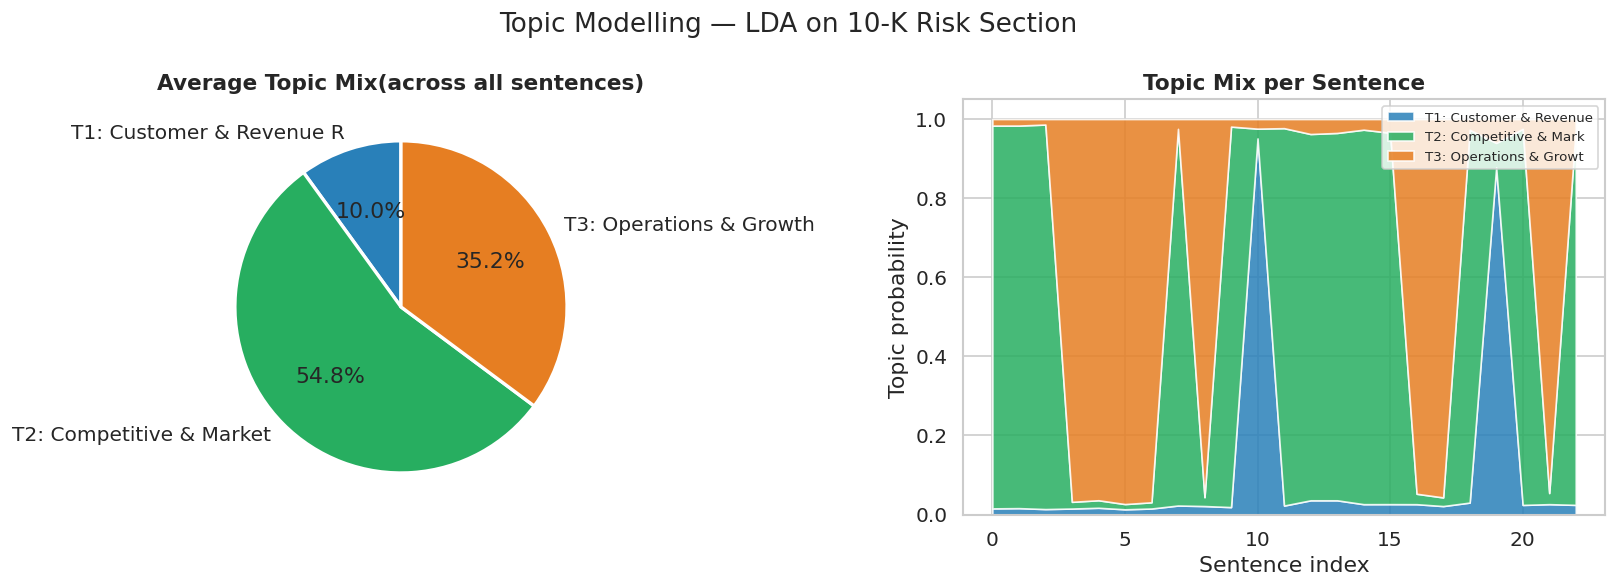


✅ Topic modelling complete


In [20]:
# ── Preprocess sentences for topic modelling ──────────────────────────────────
stop_set = set(stopwords.words('english'))
lem      = WordNetLemmatizer()

def preprocess(sentences):
    docs = []
    for s in sentences:
        tokens = [lem.lemmatize(w.lower()) for w in word_tokenize(s)
                  if w.isalpha() and w.lower() not in stop_set and len(w) > 2]
        if tokens:
            docs.append(tokens)
    return docs

processed = preprocess(sentences)
dictionary = Dictionary(processed)
dictionary.filter_extremes(no_below=1, no_above=0.95)
corpus = [dictionary.doc2bow(d) for d in processed]

print(f"Corpus: {len(corpus)} documents | Dictionary: {len(dictionary)} terms")

# ── LDA ───────────────────────────────────────────────────────────────────────
NUM_TOPICS = 3
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS,
               random_state=42, passes=15, per_word_topics=True)

print("\nLDA — DISCOVERED TOPICS:")
print("=" * 65)
topic_labels = ["Customer & Revenue Risk", "Competitive & Market Risk", "Operations & Growth Risk"]
for idx, topic in lda.print_topics(-1, num_words=8):
    top_words = [w.split('"')[1] for w in topic.split('+')]
    print(f"  Topic {idx+1} ({topic_labels[idx]}): {', '.join(top_words)}")

# ── Document-topic assignments ────────────────────────────────────────────────
print("\nDOCUMENT-TOPIC ASSIGNMENTS (first 6 sentences):")
print("-" * 65)
for i, (doc_bow, doc_text) in enumerate(zip(corpus[:6], processed[:6])):
    dist = sorted(lda.get_document_topics(doc_bow), key=lambda x: x[1], reverse=True)
    top_topic = dist[0][0]
    top_prob  = dist[0][1]
    print(f"  [{i+1}] {' '.join(doc_text[:8])}…")
    print(f"       → {topic_labels[top_topic]}  ({top_prob:.1%})")

# ── NMF ───────────────────────────────────────────────────────────────────────
tv_nmf  = TfidfVectorizer(max_features=100, stop_words='english', min_df=1)
X_nmf   = tv_nmf.fit_transform([' '.join(d) for d in processed])
nmf_mdl = NMF(n_components=NUM_TOPICS, random_state=42, init='nndsvda', max_iter=500)
nmf_mdl.fit(X_nmf)
vocab   = tv_nmf.get_feature_names_out()

print("\nNMF — TOPICS:")
print("=" * 55)
for i, comp in enumerate(nmf_mdl.components_):
    top = [vocab[j] for j in comp.argsort()[-8:][::-1]]
    print(f"  Topic {i+1}: {', '.join(top)}")

# ── Visualise topic distributions ─────────────────────────────────────────────
topic_dist = np.zeros((len(corpus), NUM_TOPICS))
for i, doc_bow in enumerate(corpus):
    for t, p in lda.get_document_topics(doc_bow):
        topic_dist[i, t] = p

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Topic Modelling — LDA on 10-K Risk Section")

colors_topic = [COLOR_MAIN, COLOR_POS, COLOR_UNC]
avg_dist = topic_dist.mean(axis=0)
axes[0].pie(avg_dist, labels=[f"T{i+1}: {l[:20]}" for i, l in enumerate(topic_labels)],
            colors=colors_topic, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title("Average Topic Mix(across all sentences)")

axes[1].stackplot(range(len(topic_dist)), topic_dist.T,
                  labels=[f"T{i+1}: {l[:18]}" for i, l in enumerate(topic_labels)],
                  colors=colors_topic, alpha=0.85)
axes[1].set_title("Topic Mix per Sentence")
axes[1].set_xlabel("Sentence index")
axes[1].set_ylabel("Topic probability")
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
print("\n✅ Topic modelling complete")

## Integrated Analytics Dashboard

We now combine every technique into a **single summary dashboard** — the kind of output you would deliver to an analyst or portfolio manager.

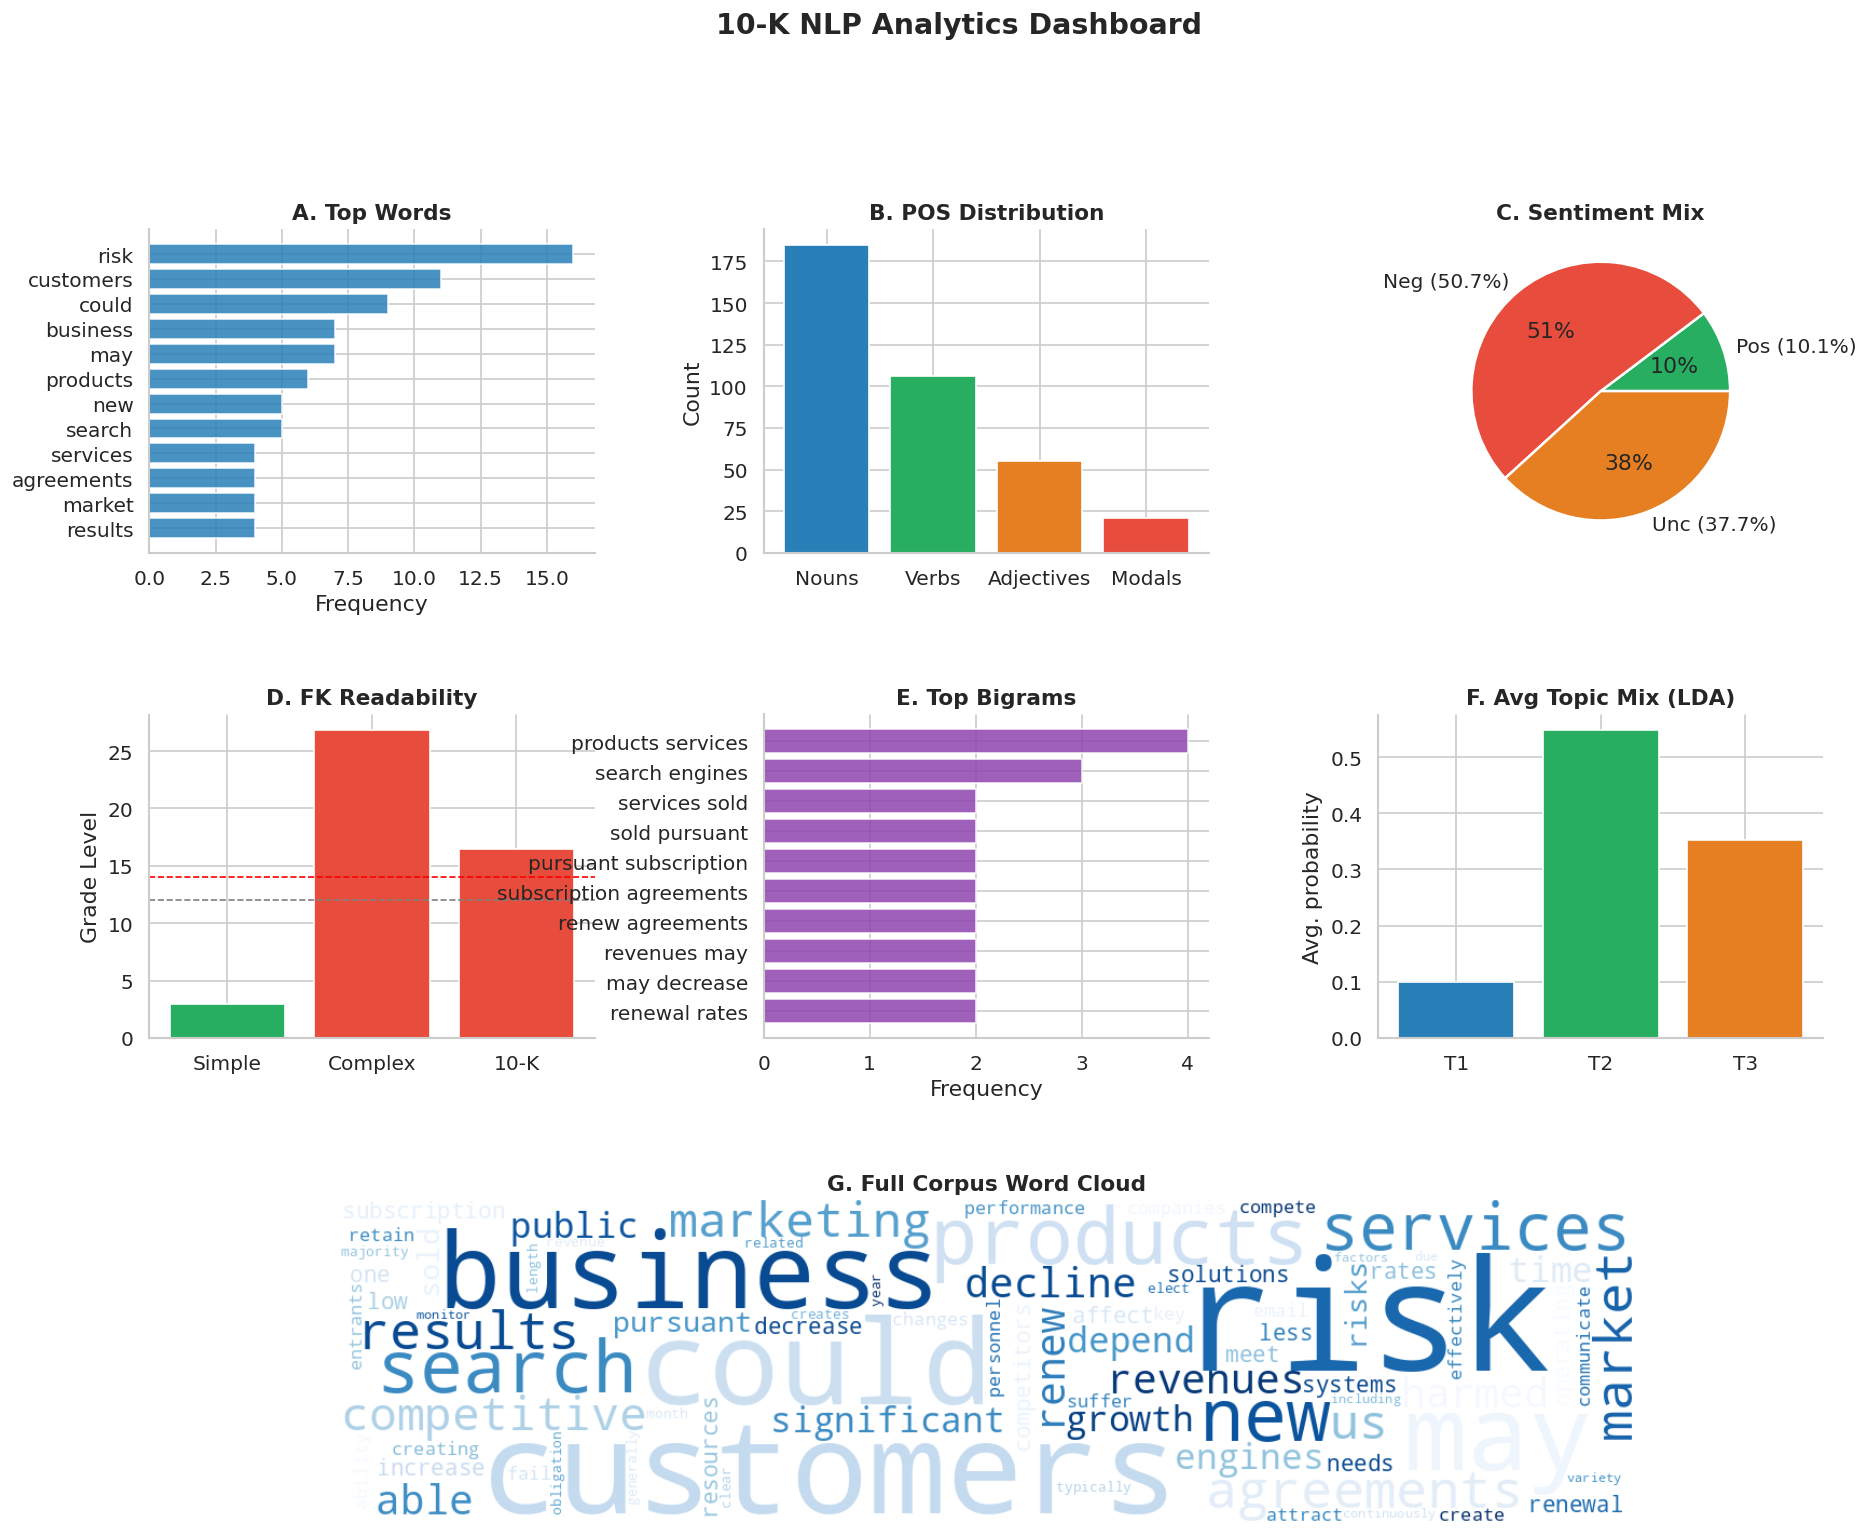

📊 Dashboard rendered and saved to 'nlp_dashboard.png'


In [21]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("10-K NLP Analytics Dashboard", fontsize=17, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── A: Word frequency (top 12) ─────────────────────────────────────────────────
ax_freq = fig.add_subplot(gs[0, 0])
words_top12, counts_top12 = zip(*word_freq.most_common(12))
ax_freq.barh(list(words_top12), list(counts_top12), color=COLOR_MAIN, edgecolor='white', alpha=0.85)
ax_freq.invert_yaxis()
ax_freq.set_title("A. Top Words", fontweight='bold')
ax_freq.set_xlabel("Frequency")
sns.despine(ax=ax_freq)

# ── B: POS distribution ────────────────────────────────────────────────────────
ax_pos = fig.add_subplot(gs[0, 1])
pos_counts = {"Nouns": len(nouns), "Verbs": len(verbs), "Adjectives": len(adjectives), "Modals": len(modals)}
ax_pos.bar(pos_counts.keys(), pos_counts.values(),
           color=[COLOR_MAIN, COLOR_POS, COLOR_UNC, COLOR_NEG], edgecolor='white')
ax_pos.set_title("B. POS Distribution", fontweight='bold')
ax_pos.set_ylabel("Count")
sns.despine(ax=ax_pos)

# ── C: Sentiment pie ──────────────────────────────────────────────────────────
ax_sent = fig.add_subplot(gs[0, 2])
pie_vals  = [result["positive"], result["negative"], result["uncertain"]]
pie_cols  = [COLOR_POS, COLOR_NEG, COLOR_UNC]
pie_labs  = [f"Pos ({result['pos_pct']}%)", f"Neg ({result['neg_pct']}%)", f"Unc ({result['unc_pct']}%)"]
ax_sent.pie(pie_vals, labels=pie_labs, colors=pie_cols, autopct='%1.0f%%',
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax_sent.set_title("C. Sentiment Mix", fontweight='bold')

# ── D: Readability bar ────────────────────────────────────────────────────────
ax_read = fig.add_subplot(gs[1, 0])
read_labels = ["Simple", "Complex", "10-K"]
fk_vals     = [textstat.flesch_kincaid_grade(t) for t in [simple_text, complex_text, financial_text]]
bar_colors  = [COLOR_POS if v<12 else COLOR_UNC if v<14 else COLOR_NEG for v in fk_vals]
ax_read.bar(read_labels, fk_vals, color=bar_colors, edgecolor='white')
ax_read.axhline(12, linestyle='--', color='gray', linewidth=1)
ax_read.axhline(14, linestyle='--', color='red',  linewidth=1)
ax_read.set_title("D. FK Readability", fontweight='bold')
ax_read.set_ylabel("Grade Level")
sns.despine(ax=ax_read)

# ── E: Top bigrams ────────────────────────────────────────────────────────────
ax_bg = fig.add_subplot(gs[1, 1])
bg_words, bg_counts = zip(*bigram_freq.most_common(10))
ax_bg.barh(list(bg_words), list(bg_counts), color="#8e44ad", edgecolor='white', alpha=0.85)
ax_bg.invert_yaxis()
ax_bg.set_title("E. Top Bigrams", fontweight='bold')
ax_bg.set_xlabel("Frequency")
sns.despine(ax=ax_bg)

# ── F: Topic mix stacked bar ──────────────────────────────────────────────────
ax_top = fig.add_subplot(gs[1, 2])
topic_means = topic_dist.mean(axis=0)
ax_top.bar(range(NUM_TOPICS),
           topic_means,
           color=[COLOR_MAIN, COLOR_POS, COLOR_UNC], edgecolor='white')
ax_top.set_xticks(range(NUM_TOPICS))
ax_top.set_xticklabels([f"T{i+1}" for i in range(NUM_TOPICS)])
ax_top.set_title("F. Avg Topic Mix (LDA)", fontweight='bold')
ax_top.set_ylabel("Avg. probability")
sns.despine(ax=ax_top)

# ── G: Word cloud ─────────────────────────────────────────────────────────────
ax_wc = fig.add_subplot(gs[2, :])
wc_dash = WordCloud(width=1200, height=300, background_color='white',
                    colormap='Blues', max_words=80).generate_from_frequencies(word_freq)
ax_wc.imshow(wc_dash, interpolation='bilinear')
ax_wc.axis('off')
ax_wc.set_title("G. Full Corpus Word Cloud", fontweight='bold')

plt.tight_layout()
plt.savefig("nlp_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Dashboard rendered and saved to 'nlp_dashboard.png'")

## Key Takeaways

|  | Technique | Financial Signal Extracted |
|---|-----------|---------------------------|
| 1 | Tokenisation | Document structure; avg sentence length |
| 2 | Stemming / Lemmatisation | Unified risk concept counts |
| 3 | Stop-word removal | 40–50% noise reduction |
| 4 | Word frequency | Risk-score; thematic concentration |
| 5 | N-grams | Domain phrases: "material weakness", "revenue decline" |
| 6 | POS tagging | Noun entities, verb events, adjective severity, modal hedging |
| 7 | BoW / TF-IDF | Numerical representation for ML models |
| 8 | Document similarity | Peer grouping; year-over-year change detection |
| 9 | Readability | Transparency signal; obfuscation detection |
| 10 | Sentiment (domain-aware) | Management tone; optimism/pessimism bias |
| 11 | Topic modelling | Automatic risk category discovery |

---